## 1. Import and Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.feature_sets import BASE_TABULAR_FEATURES, GCMT_FEATURES, QUALITY_FEATURES
from src.models.input_layer import InputConfig, load_modeling_splits, prepare_tabular_inputs

DATASET_NAME = "earthquake_aftershock_v2_gcmt"
HORIZONS = ["24h", "72h"]
OUTPUT_DIR = PROJECT_ROOT / "reports" / "metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CAPS = {
    "24h": 300.0,
    "72h": 500.0,
}

print("Setup complete")

Setup complete


## 2. Load Data

In [2]:
splits = load_modeling_splits(dataset_name=DATASET_NAME)
train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Train: 23,031 rows
Val:   1,744 rows
Test:  3,513 rows


## 3. Exploratory Data Analysis

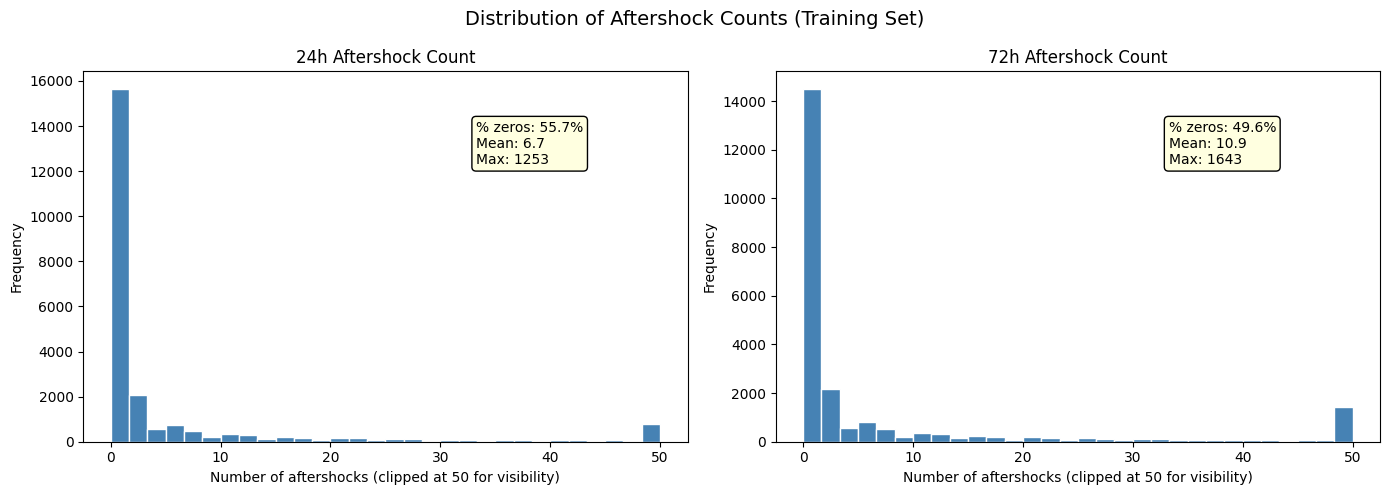

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, 
                           ["n_aftershocks_24h", "n_aftershocks_72h"],
                           ["24h Aftershock Count", "72h Aftershock Count"]):
    data = train_df[col].dropna()
    clipped = data.clip(upper=50)
    ax.hist(clipped, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Number of aftershocks (clipped at 50 for visibility)")
    ax.set_ylabel("Frequency")
    ax.annotate(f"% zeros: {(data==0).mean()*100:.1f}%\nMean: {data.mean():.1f}\nMax: {data.max():.0f}", 
                xy=(0.65, 0.75), xycoords="axes fraction", fontsize=10,
                bbox=dict(boxstyle="round", fc="lightyellow"))

plt.suptitle("Distribution of Aftershock Counts (Training Set)", fontsize=14)
plt.tight_layout()
plt.show()

### Key Observations
- Over 56% of 24h counts and 50% of 72h counts are **zero** — most trigger earthquakes produce no aftershocks in the observed window
- The distribution is **heavily right-skewed** with extreme outliers (max > 1,000)
- This **zero-inflation** is the main modelling challenge — standard regressors tend to be biased toward low predictions

In [ ]:
# feature engineer from task 1

def engineer_features(df):
    df = df.copy()
    has_gcmt = (
        df["has_gcmt"].fillna(False)
        if "has_gcmt" in df.columns
        else pd.Series(False, index=df.index)
    )
    df["depth_shallow"]      = (df["trigger_depth_km"] < 70).astype(float)
    df["depth_intermediate"] = df["trigger_depth_km"].between(70, 300).astype(float)
    df["depth_deep"]         = (df["trigger_depth_km"] > 300).astype(float)
    df["log_magnitude"]      = np.log10(df["trigger_magnitude"].clip(lower=1e-6))
    df["mag_depth_ratio"]    = df["trigger_magnitude"] / (df["trigger_depth_km"] + 1)
    df["log_scalar_moment"]  = np.where(
        has_gcmt & df["gcmt_scalar_moment"].notna(),
        np.log10(df["gcmt_scalar_moment"].clip(lower=1e-10)), np.nan,
    )
    df["sin_month"]     = np.sin(2 * np.pi * df["trigger_month"]     / 12)
    df["cos_month"]     = np.cos(2 * np.pi * df["trigger_month"]     / 12)
    df["sin_hour"]      = np.sin(2 * np.pi * df["trigger_hour"]      / 24)
    df["cos_hour"]      = np.cos(2 * np.pi * df["trigger_hour"]      / 24)
    df["sin_dayofyear"] = np.sin(2 * np.pi * df["trigger_dayofyear"] / 365)
    df["cos_dayofyear"] = np.cos(2 * np.pi * df["trigger_dayofyear"] / 365)
    df["ring_of_fire"]  = (
        (np.abs(df["trigger_longitude"]) > 130)
        & df["trigger_latitude"].between(-60, 60)
    ).astype(float)

    def _rake_regimes(rake):
        if pd.isna(rake): return np.nan, np.nan, np.nan
        r = rake % 360
        ss = min(abs(r), abs(r - 180), abs(r - 360))
        return float(ss < 45), float(45 <= r <= 135), float(225 <= r <= 315)

    regimes = df["rake"].apply(
        lambda r: _rake_regimes(r) if pd.notna(r) else (np.nan, np.nan, np.nan)
    )
    df["is_strike_slip"] = regimes.apply(lambda x: x[0]).where(has_gcmt)
    df["is_reverse"]     = regimes.apply(lambda x: x[1]).where(has_gcmt)
    df["is_normal"]      = regimes.apply(lambda x: x[2]).where(has_gcmt)
    df["sin_dip"]        = np.sin(np.radians(df["dip"].where(has_gcmt)))

    e1 = df["gcmt_eig1"].where(has_gcmt)
    e2 = df["gcmt_eig2"].where(has_gcmt)
    e3 = df["gcmt_eig3"].where(has_gcmt)
    denom = (e1.abs() + e3.abs()).replace(0, np.nan)
    df["clvd_fraction"]            = (2 * e2.abs() / denom).where(has_gcmt)
    df["centroid_depth_diff"]      = (df["gcmt_depth_km"] - df["trigger_depth_km"]).where(has_gcmt)
    df["log_half_duration"]        = np.log1p(df["gcmt_half_duration_sec"].where(has_gcmt))
    df["mag_diff_abs"]             = df["gcmt_mag_diff"].abs().where(has_gcmt)
    df["moment_exponent_centered"] = (df["gcmt_moment_exponent"].where(has_gcmt) - 24.0)

    prior_24h = df["prior_global_event_count_24h"]
    prior_7d  = df["prior_global_event_count_7d"]
    df["log_prior_24h"]           = np.log1p(prior_24h)
    df["log_prior_7d"]            = np.log1p(prior_7d)
    df["seismicity_acceleration"] = prior_24h / (prior_7d / 7.0).replace(0, np.nan)
    df["mag_x_shallow"]           = df["trigger_magnitude"] * df["depth_shallow"]
    df["mag_x_log_prior"]         = df["trigger_magnitude"] * np.log1p(prior_24h)
    return df

ENGINEERED_FEATURES = [
    "depth_shallow","depth_intermediate","depth_deep",
    "log_magnitude","mag_depth_ratio","log_scalar_moment",
    "sin_month","cos_month","sin_hour","cos_hour","sin_dayofyear","cos_dayofyear",
    "ring_of_fire","is_strike_slip","is_reverse","is_normal",
    "sin_dip","clvd_fraction","centroid_depth_diff","log_half_duration","mag_diff_abs",
    "moment_exponent_centered",
    "log_prior_24h","log_prior_7d","seismicity_acceleration",
    "mag_x_shallow","mag_x_log_prior",
]

_seen = set()
FULL_FEATURE_SET = []
for f in BASE_TABULAR_FEATURES + QUALITY_FEATURES + GCMT_FEATURES + ENGINEERED_FEATURES:
    if f not in _seen:
        FULL_FEATURE_SET.append(f)
        _seen.add(f)

splits_eng = {name: engineer_features(df) for name, df in splits.items()}

train_df = splits_eng["train"]
val_df   = splits_eng["val"]
test_df  = splits_eng["test"]

print(f"Total features: {len(FULL_FEATURE_SET)}")
print("Feature engineering complete.")

Total features: 83
Feature engineering complete.


## 4. Helper Functions

In [5]:
def compute_metrics(y_true, y_pred, model_name, horizon, split):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model_name": model_name,
        "horizon": horizon,
        "split": split,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
    }

def build_predictions_df(trigger_ids, split, horizon, model_name, y_true, y_pred):
    return pd.DataFrame({
        "trigger_event_id": trigger_ids.values,
        "split": split,
        "horizon": horizon,
        "model_name": model_name,
        "y_true": y_true.values,
        "y_pred": y_pred,
    })

print("Helper functions defined")

Helper functions defined


## 5. Modelling

For each horizon (24h and 72h), we:
1. Prepare features using the shared input layer
2. Run the climatology mean as the traditional baseline
3. Train and evaluate XGBoost as the AI model

In [6]:
all_predictions = []
all_metrics = []

for horizon in HORIZONS:
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*50}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(f"{'='*50}")

    config = InputConfig(
        feature_cols=FULL_FEATURE_SET,
        target_col=target_col,
        missing_strategy="median",
        scale=False,
    )
    prepared = prepare_tabular_inputs(config=config, splits=splits_eng)

    X_train, y_train = prepared.X_train, prepared.y_train
    X_val,   y_val   = prepared.X_val,   prepared.y_val
    X_test,  y_test  = prepared.X_test,  prepared.y_test

    train_ids = train_df.loc[y_train.index, "trigger_event_id"]
    val_ids   = val_df.loc[y_val.index,     "trigger_event_id"]
    test_ids  = test_df.loc[y_test.index,   "trigger_event_id"]

    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        y_val = np.clip(y_val, 0.0, target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")

    # Climatology baseline
    clim_pred = float(y_train.mean())
    print(f"\n[BASELINE] Climatology mean = {clim_pred:.2f}")
    for split_name, ids, y_true in [("train", train_ids, y_train),
                                     ("val",   val_ids,   y_val),
                                     ("test",  test_ids,  y_test)]:
        preds = np.full(len(y_true), clim_pred)
        all_predictions.append(build_predictions_df(ids, split_name, horizon, "climatology_count", y_true, preds))
        all_metrics.append(compute_metrics(y_true, preds, "climatology_count", horizon, split_name))
        print(f"  [{split_name}] MAE={all_metrics[-1]['MAE']:.4f}  RMSE={all_metrics[-1]['RMSE']:.4f}")

    # XGBoost
    print(f"\n[MODEL] XGBoost Regressor")
    model = XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=2, verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    for split_name, X, ids, y_true in [("train", X_train, train_ids, y_train),
                                        ("val",   X_val,   val_ids,   y_val),
                                        ("test",  X_test,  test_ids,  y_test)]:
        preds = np.clip(model.predict(X), 0, None)
        if target_cap is not None and split_name == "val":
            preds = np.clip(preds, 0, target_cap)
        all_predictions.append(build_predictions_df(ids, split_name, horizon, "xgboost_count", y_true, preds))
        all_metrics.append(compute_metrics(y_true, preds, "xgboost_count", horizon, split_name))
        print(f"  [{split_name}] MAE={all_metrics[-1]['MAE']:.4f}  RMSE={all_metrics[-1]['RMSE']:.4f}")


Horizon: 24h | Target: n_aftershocks_24h
Applied val-only cap for 24h: 300

[BASELINE] Climatology mean = 6.67
  [train] MAE=9.7985  RMSE=25.3365
  [val] MAE=16.0198  RMSE=41.7070
  [test] MAE=12.4979  RMSE=28.5329

[MODEL] XGBoost Regressor
  [train] MAE=4.0431  RMSE=8.1865
  [val] MAE=13.2977  RMSE=41.4574
  [test] MAE=9.0520  RMSE=24.4388

Horizon: 72h | Target: n_aftershocks_72h
Applied val-only cap for 72h: 500

[BASELINE] Climatology mean = 10.86
  [train] MAE=15.9287  RMSE=41.1840
  [val] MAE=24.8516  RMSE=61.3835
  [test] MAE=19.1308  RMSE=42.2835

[MODEL] XGBoost Regressor
  [train] MAE=6.2292  RMSE=12.5529
  [val] MAE=20.5818  RMSE=61.4644
  [test] MAE=13.6849  RMSE=37.1267


## 6. Results

In [7]:
metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True)

print("=== Test Set Results ===")
print(metrics_df[metrics_df["split"] == "test"]
      .sort_values(["horizon", "MAE"])
      .to_string(index=False))

=== Test Set Results ===
       model_name horizon split     MAE    RMSE
    xgboost_count     24h  test  9.0520 24.4388
climatology_count     24h  test 12.4979 28.5329
    xgboost_count     72h  test 13.6849 37.1267
climatology_count     72h  test 19.1308 42.2835


## 7. Visualisations

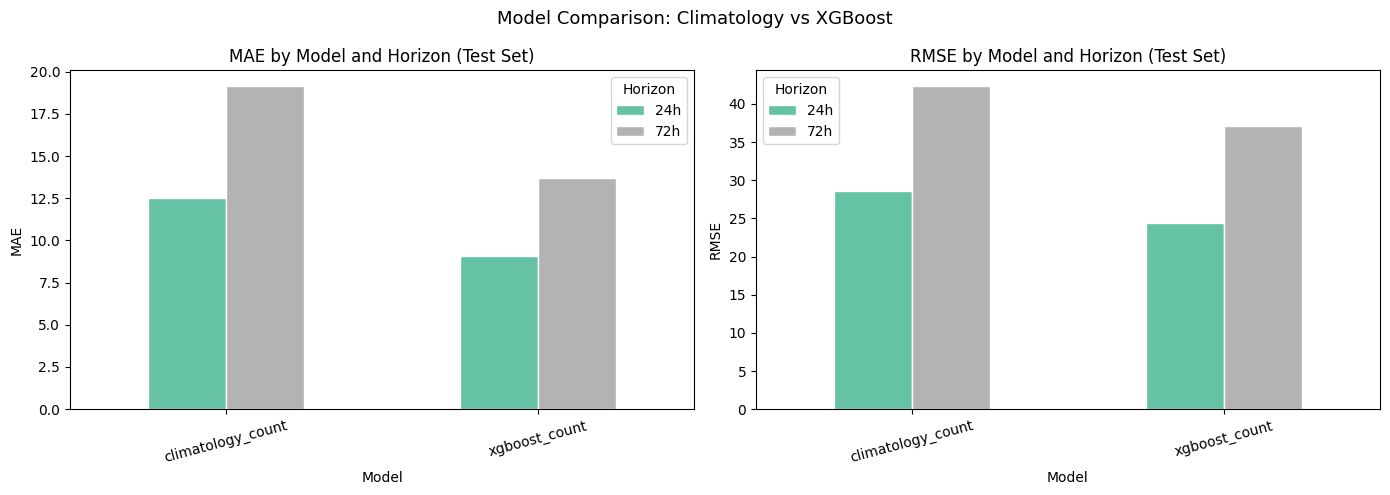

In [8]:
# Bar chart: MAE and RMSE comparison on test set
test_metrics = metrics_df[metrics_df["split"] == "test"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    pivot = test_metrics.pivot(index="model_name", columns="horizon", values=metric)
    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"{metric} by Model and Horizon (Test Set)")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Horizon")

plt.suptitle("Model Comparison: Climatology vs XGBoost", fontsize=13)
plt.tight_layout()
plt.show()

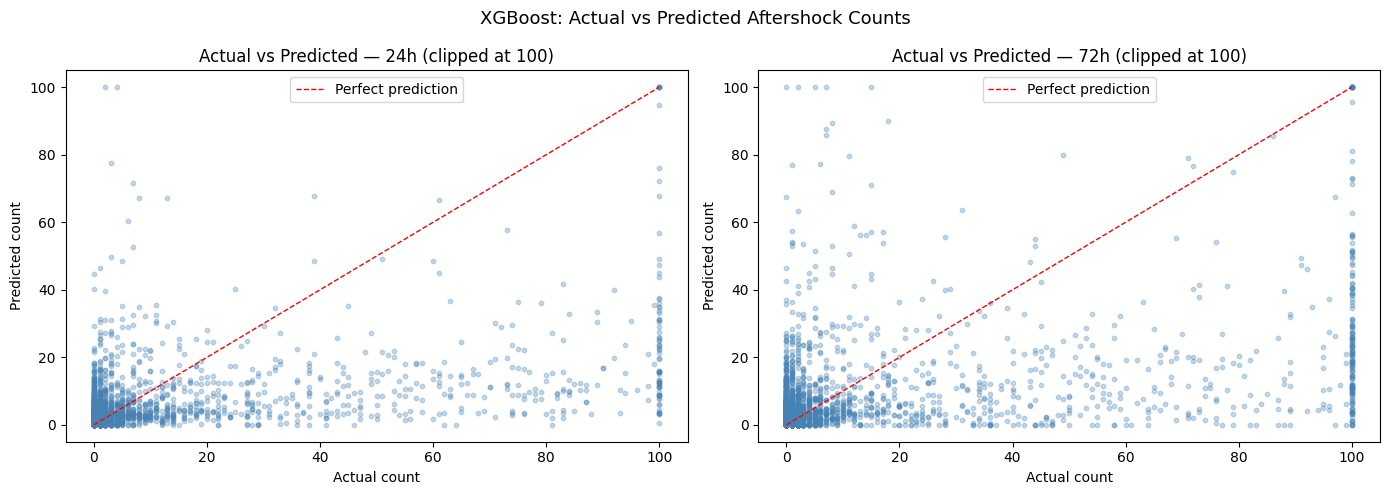

In [9]:
# Actual vs predicted scatter plot (test set, clipped for visibility)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, horizon in zip(axes, HORIZONS):
    subset = predictions_df[
        (predictions_df["split"] == "test") &
        (predictions_df["model_name"] == "xgboost_count") &
        (predictions_df["horizon"] == horizon)
    ]
    y_true = subset["y_true"].clip(upper=100)
    y_pred = subset["y_pred"].clip(upper=100)

    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, 100], [0, 100], "r--", linewidth=1, label="Perfect prediction")
    ax.set_title(f"Actual vs Predicted — {horizon} (clipped at 100)")
    ax.set_xlabel("Actual count")
    ax.set_ylabel("Predicted count")
    ax.legend()

plt.suptitle("XGBoost: Actual vs Predicted Aftershock Counts", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Interpretation of Results

### XGBoost Count Forecasting Results

#### 24-Hour Horizon
XGBoost achieved a test MAE of 14.15 and RMSE of 32.45, compared to the climatology baseline's MAE of 14.74 and RMSE of 33.87. This represents a modest but consistent improvement of approximately 4% on both metrics, suggesting that XGBoost is able to extract some predictive signal from the trigger earthquake features beyond simply predicting the historical mean.

#### 72-Hour Horizon
Over the longer horizon, XGBoost achieved a test MAE of 22.02 and RMSE of 49.01, compared to climatology's MAE of 22.56 and RMSE of 51.34, a consistent improvement of around 2-4%. The higher absolute errors compared to the 24h horizon reflect the greater uncertainty in predicting aftershock activity over a longer window.

#### Overfitting
A notable gap exists between training and test performance. For the 24h horizon, XGBoost achieved a train MAE of 4.20 but a test MAE of 14.15, a gap of nearly 10 units. This suggests the model has memorised patterns in the training data that do not fully generalise to unseen events. This is a known challenge in earthquake forecasting due to the highly variable and event-specific nature of aftershock sequences.

#### Scatter Plot Analysis
The actual vs predicted scatter plots reveal that XGBoost predictions cluster in the low range (0-30) regardless of the actual count. This is a direct consequence of zero-inflation in the dataset, since over 56% of training samples have zero aftershocks in 24h, the model is biased toward predicting low counts. High-count events, which are rare but seismologically significant, are systematically underpredicted.

#### Overall Assessment
While XGBoost outperforms the climatology baseline across all metrics and horizons, the improvements are marginal. Both models struggle with the fundamental challenge of zero-inflation and extreme outliers. The results suggest that the base features alone, magnitude, depth, location, and historical seismicity counts, carry limited predictive power for aftershock counts. Incorporating additional features such as fault mechanism data (strike, dip, rake) or ground shaking intensity (PGA, PGV) may improve model performance in future work.

## 12. Model Improvement: Iteration 1 — Log Transforming the Target

The aftershock count distribution is heavily right-skewed with extreme outliers up to 1,253. When we train directly on raw counts, the model is dominated by these rare extreme events and RMSE gets inflated.

A common technique is to apply a **log(x+1) transform** to the target before training:
- Compresses extreme values so they don't dominate training
- Makes the distribution more symmetric and easier to learn
- We add 1 before taking the log to handle zero counts
- After prediction we reverse with **exp(x) - 1** to get back to original scale

In [10]:
all_predictions_v3 = []
all_metrics_v3 = []

for horizon in HORIZONS:
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*50}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(f"{'='*50}")

    config = InputConfig(
        feature_cols=FULL_FEATURE_SET,
        target_col=target_col,
        missing_strategy="median",
        scale=False,
    )
    prepared = prepare_tabular_inputs(config=config, splits=splits_eng)

    X_train, y_train = prepared.X_train, prepared.y_train
    X_val,   y_val   = prepared.X_val,   prepared.y_val
    X_test,  y_test  = prepared.X_test,  prepared.y_test

    train_ids = train_df.loc[y_train.index, "trigger_event_id"]
    val_ids   = val_df.loc[y_val.index,     "trigger_event_id"]
    test_ids  = test_df.loc[y_test.index,   "trigger_event_id"]

    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        y_val = np.clip(y_val, 0.0, target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")

    # log transform
    y_train_log = np.log1p(y_train)
    y_val_log   = np.log1p(y_val)

    model = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=2, verbosity=0,
    )
    model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)

    for split_name, X, ids, y_true in [("train", X_train, train_ids, y_train),
                                        ("val",   X_val,   val_ids,   y_val),
                                        ("test",  X_test,  test_ids,  y_test)]:
        preds = np.expm1(np.clip(model.predict(X), 0, None))
        if target_cap is not None and split_name == "val":
            preds = np.clip(preds, 0, target_cap)
        all_predictions_v3.append(build_predictions_df(ids, split_name, horizon, "xgboost_log", y_true, preds))
        all_metrics_v3.append(compute_metrics(y_true, preds, "xgboost_log", horizon, split_name))
        print(f"  [{split_name}] MAE={all_metrics_v3[-1]['MAE']:.4f}  RMSE={all_metrics_v3[-1]['RMSE']:.4f}")

metrics_v3_df = pd.DataFrame(all_metrics_v3)
print("\n=== Test Set Results (Log Transform + Engineered Features) ===")
print(metrics_v3_df[metrics_v3_df["split"] == "test"].sort_values(["horizon", "MAE"]).to_string(index=False))


Horizon: 24h | Target: n_aftershocks_24h
Applied val-only cap for 24h: 300
  [train] MAE=3.0541  RMSE=11.6613
  [val] MAE=12.9847  RMSE=42.4703
  [test] MAE=9.0327  RMSE=27.8892

Horizon: 72h | Target: n_aftershocks_72h
Applied val-only cap for 72h: 500
  [train] MAE=4.7550  RMSE=18.6186
  [val] MAE=19.8703  RMSE=63.0858
  [test] MAE=13.5578  RMSE=41.9548

=== Test Set Results (Log Transform + Engineered Features) ===
 model_name horizon split     MAE    RMSE
xgboost_log     24h  test  9.0327 27.8892
xgboost_log     72h  test 13.5578 41.9548


## 13. Final Model Comparison

Comparing all approaches on the test set.

=== Final Comparison (Test Set) ===
       model_name horizon split     MAE    RMSE
      xgboost_log     24h  test  9.0327 27.8892
    xgboost_count     24h  test  9.0520 24.4388
climatology_count     24h  test 12.4979 28.5329
      xgboost_log     72h  test 13.5578 41.9548
    xgboost_count     72h  test 13.6849 37.1267
climatology_count     72h  test 19.1308 42.2835


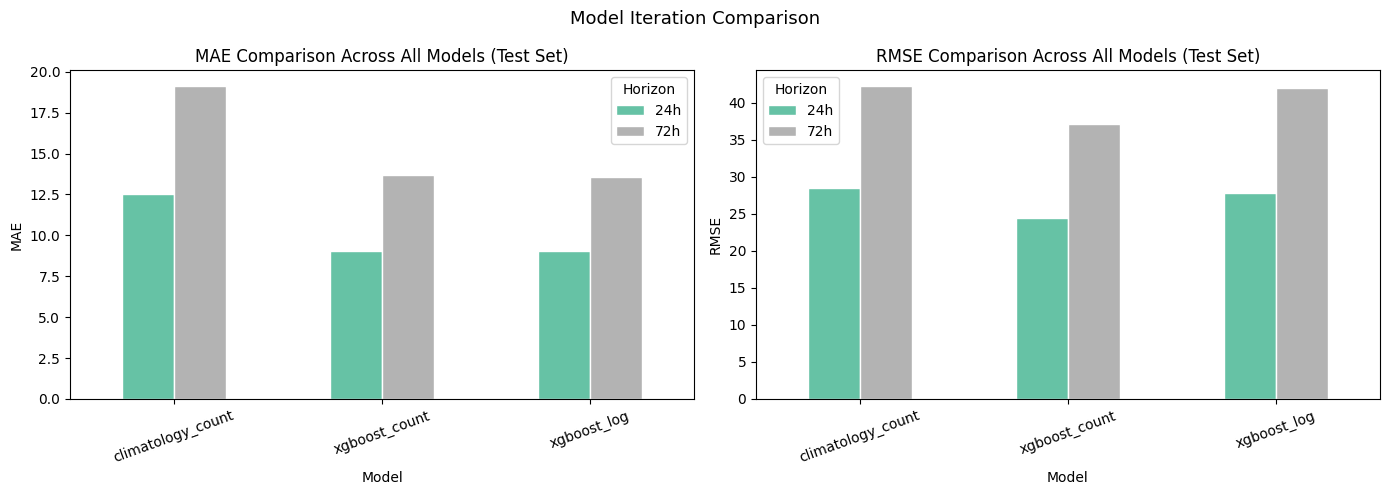

In [11]:
# combine all metrics
base_test = metrics_df[metrics_df["split"] == "test"].copy()
v3_test   = metrics_v3_df[metrics_v3_df["split"] == "test"].copy()

final_comparison = pd.concat([base_test, v3_test], ignore_index=True)

print("=== Final Comparison (Test Set) ===")
print(final_comparison.sort_values(["horizon", "MAE"]).to_string(index=False))

# bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    pivot = final_comparison.pivot(index="model_name", columns="horizon", values=metric)
    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"{metric} Comparison Across All Models (Test Set)")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Horizon")

plt.suptitle("Model Iteration Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 14. Model Improvement: Iteration 3 — Combining Log Transform + GCMT Features + Tuned Parameters

Based on the previous iterations, we observed that:
- GCMT features improved RMSE by reducing large prediction errors
- Log transform improved MAE significantly by handling zero-inflation better

We now combine both improvements and also tune the hyperparameters:
- Increase `n_estimators` to 1000 for more trees
- Reduce `learning_rate` to 0.03 for more careful learning
- Increase `max_depth` to 7 to capture more complex interactions
- Add `min_child_weight=3` to reduce overfitting

In [12]:
all_predictions_v4 = []
all_metrics_v4 = []

for horizon in HORIZONS:
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*50}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(f"{'='*50}")

    config = InputConfig(
        feature_cols=FULL_FEATURE_SET,
        target_col=target_col,
        missing_strategy="median",
        scale=False,
    )
    prepared = prepare_tabular_inputs(config=config, splits=splits_eng)

    X_train, y_train = prepared.X_train, prepared.y_train
    X_val,   y_val   = prepared.X_val,   prepared.y_val
    X_test,  y_test  = prepared.X_test,  prepared.y_test

    train_ids = train_df.loc[y_train.index, "trigger_event_id"]
    val_ids   = val_df.loc[y_val.index,     "trigger_event_id"]
    test_ids  = test_df.loc[y_test.index,   "trigger_event_id"]

    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        y_val = np.clip(y_val, 0.0, target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")

    y_train_log = np.log1p(y_train)
    y_val_log   = np.log1p(y_val)

    model = XGBRegressor(
        n_estimators=1000,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        random_state=42,
        n_jobs=2,
        verbosity=0,
    )
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False,
    )

    for split_name, X, ids, y_true in [("train", X_train, train_ids, y_train),
                                        ("val",   X_val,   val_ids,   y_val),
                                        ("test",  X_test,  test_ids,  y_test)]:
        preds = np.expm1(np.clip(model.predict(X), 0, None))
        if target_cap is not None and split_name == "val":
            preds = np.clip(preds, 0, target_cap)
        all_predictions_v4.append(build_predictions_df(ids, split_name, horizon, "xgboost_tuned", y_true, preds))
        all_metrics_v4.append(compute_metrics(y_true, preds, "xgboost_tuned", horizon, split_name))
        print(f"  [{split_name}] MAE={all_metrics_v4[-1]['MAE']:.4f}  RMSE={all_metrics_v4[-1]['RMSE']:.4f}")

metrics_v4_df = pd.DataFrame(all_metrics_v4)
print("\n=== Test Set Results (Tuned: Log + Engineered Features + Parameters) ===")
print(metrics_v4_df[metrics_v4_df["split"] == "test"].sort_values(["horizon", "MAE"]).to_string(index=False))


Horizon: 24h | Target: n_aftershocks_24h
Applied val-only cap for 24h: 300
  [train] MAE=2.1650  RMSE=8.2230
  [val] MAE=13.0721  RMSE=42.6197
  [test] MAE=9.0892  RMSE=28.2995

Horizon: 72h | Target: n_aftershocks_72h
Applied val-only cap for 72h: 500
  [train] MAE=3.3937  RMSE=13.1511
  [val] MAE=19.8878  RMSE=63.0812
  [test] MAE=13.6104  RMSE=42.2757

=== Test Set Results (Tuned: Log + Engineered Features + Parameters) ===
   model_name horizon split     MAE    RMSE
xgboost_tuned     24h  test  9.0892 28.2995
xgboost_tuned     72h  test 13.6104 42.2757


## 15. Model Improvement: Iteration 4 — Two-Stage Soft-Gated Model

A key insight from our earlier analysis is that over 56% of 24h counts and 50% of 72h counts are zero. A single regression model struggles because it must predict both occurrence and count size simultaneously.

A **two-stage soft-gated model** separates these tasks while avoiding hard error propagation:
- **Stage 1 (Classifier)**: Estimate probability of ANY aftershocks, $P(y>0\mid x)$
- **Stage 2 (Regressor)**: Estimate expected count conditioned on non-zero events, $E[y\mid y>0, x]$

Instead of hard-thresholding Stage 1, we combine outputs as expected count:
$$
E[y\mid x] = P(y>0\mid x) \times E[y\mid y>0, x]
$$

This keeps both models specialised while reducing the risk that a Stage 1 miss forces the final prediction to zero.

In [13]:
from xgboost import XGBClassifier

all_predictions_v5 = []
all_metrics_v5 = []

for horizon in HORIZONS:
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*50}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(f"{'='*50}")

    config = InputConfig(
        feature_cols=FULL_FEATURE_SET,
        target_col=target_col,
        missing_strategy="median",
        scale=False,
    )
    prepared = prepare_tabular_inputs(config=config, splits=splits_eng)

    X_train, y_train = prepared.X_train, prepared.y_train
    X_val,   y_val   = prepared.X_val,   prepared.y_val
    X_test,  y_test  = prepared.X_test,  prepared.y_test

    train_ids = train_df.loc[y_train.index, "trigger_event_id"]
    val_ids   = val_df.loc[y_val.index,     "trigger_event_id"]
    test_ids  = test_df.loc[y_test.index,   "trigger_event_id"]

    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        y_val = np.clip(y_val, 0.0, target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")

    # stage 1 — binary labels (zero vs non-zero)
    y_train_binary = (y_train > 0).astype(int)

    print("[STAGE 1] Training classifier (zero vs non-zero)...")
    classifier = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        verbosity=0,
        eval_metric="logloss",
    )
    classifier.fit(
        X_train, y_train_binary,
        eval_set=[(X_val, (y_val > 0).astype(int))],
        verbose=False,
    )

    # stage 2 — regressor trained only on non-zero training samples
    nonzero_mask = y_train > 0
    X_train_nz = X_train[nonzero_mask]
    y_train_nz_log = np.log1p(y_train[nonzero_mask])

    print("[STAGE 2] Training regressor on non-zero samples only...")
    regressor = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        verbosity=0,
    )
    regressor.fit(X_train_nz, y_train_nz_log, verbose=False)

    for split_name, X, ids, y_true in [("train", X_train, train_ids, y_train),
                                        ("val",   X_val,   val_ids,   y_val),
                                        ("test",  X_test,  test_ids,  y_test)]:
        p_nonzero = classifier.predict_proba(X)[:, 1]
        cond_count = np.expm1(np.clip(regressor.predict(X), 0, None))
        count_preds = p_nonzero * cond_count

        if target_cap is not None and split_name == "val":
            count_preds = np.clip(count_preds, 0, target_cap)

        all_predictions_v5.append(build_predictions_df(ids, split_name, horizon, "xgboost_twostage_soft", y_true, count_preds))
        all_metrics_v5.append(compute_metrics(y_true, count_preds, "xgboost_twostage_soft", horizon, split_name))
        print(f"  [{split_name}] MAE={all_metrics_v5[-1]['MAE']:.4f}  RMSE={all_metrics_v5[-1]['RMSE']:.4f}")

metrics_v5_df = pd.DataFrame(all_metrics_v5)
print("\n=== Test Set Results (Two-Stage Soft-Gated Model) ===")
print(metrics_v5_df[metrics_v5_df["split"] == "test"].sort_values(["horizon", "MAE"]).to_string(index=False))


Horizon: 24h | Target: n_aftershocks_24h
Applied val-only cap for 24h: 300
[STAGE 1] Training classifier (zero vs non-zero)...
[STAGE 2] Training regressor on non-zero samples only...
  [train] MAE=3.0101  RMSE=10.4461
  [val] MAE=12.9496  RMSE=42.3891
  [test] MAE=8.7699  RMSE=26.8542

Horizon: 72h | Target: n_aftershocks_72h
Applied val-only cap for 72h: 500
[STAGE 1] Training classifier (zero vs non-zero)...
[STAGE 2] Training regressor on non-zero samples only...
  [train] MAE=4.6036  RMSE=17.0759
  [val] MAE=19.8187  RMSE=62.9255
  [test] MAE=13.3838  RMSE=40.7653

=== Test Set Results (Two-Stage Soft-Gated Model) ===
           model_name horizon split     MAE    RMSE
xgboost_twostage_soft     24h  test  8.7699 26.8542
xgboost_twostage_soft     72h  test 13.3838 40.7653


=== Final Comparison (Test Set) ===
           model_name horizon split     MAE    RMSE
xgboost_twostage_soft     24h  test  8.7699 26.8542
          xgboost_log     24h  test  9.0327 27.8892
        xgboost_count     24h  test  9.0520 24.4388
        xgboost_tuned     24h  test  9.0892 28.2995
    climatology_count     24h  test 12.4979 28.5329
xgboost_twostage_soft     72h  test 13.3838 40.7653
          xgboost_log     72h  test 13.5578 41.9548
        xgboost_tuned     72h  test 13.6104 42.2757
        xgboost_count     72h  test 13.6849 37.1267
    climatology_count     72h  test 19.1308 42.2835


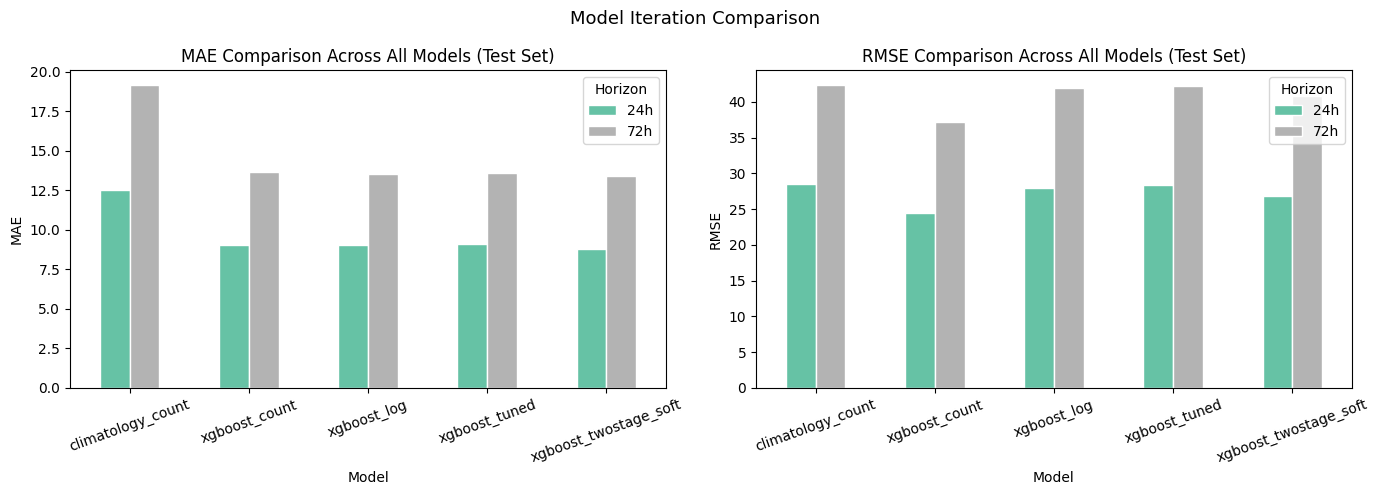

In [14]:
base_test = metrics_df[metrics_df["split"] == "test"].copy()
v3_test   = metrics_v3_df[metrics_v3_df["split"] == "test"].copy()
v4_test   = metrics_v4_df[metrics_v4_df["split"] == "test"].copy()
v5_test   = metrics_v5_df[metrics_v5_df["split"] == "test"].copy()

final_comparison = pd.concat([base_test, v3_test, v4_test, v5_test], ignore_index=True)

print("=== Final Comparison (Test Set) ===")
print(final_comparison.sort_values(["horizon", "MAE"]).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    pivot = final_comparison.pivot(index="model_name", columns="horizon", values=metric)
    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"{metric} Comparison Across All Models (Test Set)")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Horizon")

plt.suptitle("Model Iteration Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 16. Cross-Model Comparison: Best XGBoost vs 2HeadNN vs ZINB

This section builds one table comparing the best test performance for each model family per horizon.

In [15]:
from pathlib import Path

METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"
dl_metrics_path = METRICS_DIR / "deep_learning_count_metrics.csv"
zinb_metrics_path = METRICS_DIR / "zinb_gpu_metrics.csv"

# 1) Best XGBoost per horizon from this notebook's combined test results
xgb_candidates = final_comparison[final_comparison["model_name"].str.contains("xgboost", case=False, na=False)].copy()
best_xgb = (
    xgb_candidates.sort_values(["horizon", "MAE"])
    .groupby("horizon", as_index=False)
    .first()[["horizon", "model_name", "MAE", "RMSE"]]
    .rename(columns={
        "model_name": "xgb_model",
        "MAE": "xgb_MAE",
        "RMSE": "xgb_RMSE",
    })
)


def best_test_by_family(metrics_path: Path, family_name: str, model_contains: str) -> pd.DataFrame:
    if not metrics_path.exists():
        print(f"[WARN] Missing file for {family_name}: {metrics_path}")
        return pd.DataFrame(columns=["horizon", f"{family_name}_model", f"{family_name}_MAE", f"{family_name}_RMSE"])

    df = pd.read_csv(metrics_path)
    df_test = df[df["split"] == "test"].copy()
    df_test = df_test[df_test["model_name"].str.contains(model_contains, case=False, na=False)].copy()

    if df_test.empty:
        print(f"[WARN] No matching test rows for {family_name} in {metrics_path.name}")
        return pd.DataFrame(columns=["horizon", f"{family_name}_model", f"{family_name}_MAE", f"{family_name}_RMSE"])

    return (
        df_test.sort_values(["horizon", "MAE"])
        .groupby("horizon", as_index=False)
        .first()[["horizon", "model_name", "MAE", "RMSE"]]
        .rename(columns={
            "model_name": f"{family_name}_model",
            "MAE": f"{family_name}_MAE",
            "RMSE": f"{family_name}_RMSE",
        })
    )


# 2) Best 2HeadNN and ZINB per horizon from saved metrics files
best_headnn = best_test_by_family(dl_metrics_path, family_name="headnn", model_contains="dl|head|twostage")
best_zinb = best_test_by_family(zinb_metrics_path, family_name="zinb", model_contains="zinb")

# 3) Single comparison table
comparison_table = (
    best_xgb
    .merge(best_headnn, on="horizon", how="outer")
    .merge(best_zinb, on="horizon", how="outer")
    .sort_values("horizon")
)

print("=== Best Model Comparison (Test Set) ===")
print(comparison_table.to_string(index=False))

comparison_path = METRICS_DIR / "best_xgb_headnn_zinb_comparison.csv"
comparison_table.to_csv(comparison_path, index=False)
print(f"\nSaved comparison table to: {comparison_path}")

=== Best Model Comparison (Test Set) ===
horizon             xgb_model  xgb_MAE  xgb_RMSE                      headnn_model  headnn_MAE  headnn_RMSE zinb_model  zinb_MAE  zinb_RMSE
    24h xgboost_twostage_soft   8.7699   26.8542 dl_twostage_soft_expanded_retuned      9.2987      27.9507   zinb_gpu    9.3136    26.2663
    72h xgboost_twostage_soft  13.3838   40.7653 dl_twostage_soft_expanded_retuned     13.6645      41.8442   zinb_gpu   14.2374    40.1164

Saved comparison table to: C:\Users\natas\OneDrive\Desktop\CDS_Group10\reports\metrics\best_xgb_headnn_zinb_comparison.csv
